## 11) Load Control-Variant Checkpoints And Build Evaluation State


### 11a) Imports and User Configuration (Control Variants)


In [42]:
# 11a) Imports and user-editable evaluation inputs
import os
import glob
import json
import random
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torch.utils.data import DataLoader
from neuralop.models import RNO
from rno_functions import (
    ControlLifterSin,
    RNOControlARBroadcast,
    RNOControlARSinEmbed,
    RNOControlARGaussianActuators,
)

# User-editable settings
seed = 32
active_variant = (
    "gaussian_actuators"  # one of: broadcast, gaussian_actuators, sin_embed
)
active_dir = "/home/pk222/projects/tipping-point-forecast"

# Variant result folders (one model at a time is loaded via active_variant)
checkpoint_roots = {
    "broadcast": os.path.join(active_dir, f"heat/result_rno_{seed}_broadcast"),
    "gaussian_actuators": os.path.join(
        active_dir, f"heat/result_rno_{seed}_gaussian_actuators"
    ),
    "sin_embed": os.path.join(active_dir, f"heat/result_rno_{seed}_sin_embed"),
}

data_path = "/home/pk222/projects/PDEControl_DPC/datasets/heat_smooth_f_dataset.npz"

# Optional overrides; if None, values come from checkpoint config when available.
samples_to_load_override = 400
train_frac_override = None

# Step 12 params
rollout_h = 5
sample_id = 0
start_chunk = 0

# Step 13 params
# For multistep-finetuned checkpoints, keep eval within/near train horizon.
eval_steps = [1, 2, 4, 5, 8, 12, 20]
batch_size_eval = 128


### 11b) Resolve and Load Selected Control-Variant Checkpoint


In [43]:
# 11b) Resolve active variant checkpoint + robust torch.load (PyTorch >=2.6)
def _extract_timestamp_token(path_obj: Path):
    # Expected finetune suffix token like 20260301T220427Z before ".pt".
    stem = path_obj.stem
    token = stem.split("_")[-1]
    if len(token) == 16 and token.endswith("Z") and "T" in token:
        return token
    return None


def resolve_latest_variant_checkpoint(result_root: str, variant: str) -> str:
    root = Path(result_root)
    if not root.exists():
        raise FileNotFoundError(
            f"Result folder not found for variant={variant}: {result_root}"
        )

    # Prefer latest finetuned checkpoint by timestamp token in filename; fallback to mtime, then rno_model_last.pt.
    finetune_glob = {
        "broadcast": "rno_broadcast_finetune_seed*_H*_*.pt",
        "gaussian_actuators": "rno_gaussian_actuators_finetune_seed*_H*_*.pt",
        "sin_embed": "rno_sin_embed_finetune_seed*_H*_*.pt",
    }[variant]

    finetune_files = list(root.glob(finetune_glob))
    if finetune_files:
        with_ts = []
        without_ts = []
        for p in finetune_files:
            ts = _extract_timestamp_token(p)
            if ts is None:
                without_ts.append(p)
            else:
                with_ts.append((ts, p))

        if with_ts:
            with_ts.sort(key=lambda x: x[0])
            latest = with_ts[-1][1]
            print("Finetune checkpoints (timestamp-sorted):")
            for ts, pp in with_ts:
                marker = " <= selected" if pp == latest else ""
                print(f"  {ts} | {pp.name}{marker}")
            return str(latest)

        # Fallback when timestamp token is missing/unexpected.
        latest = max(without_ts, key=lambda p: p.stat().st_mtime)
        print(f"Selected by mtime fallback: {latest.name}")
        return str(latest)

    fallback = root / "rno_model_last.pt"
    if fallback.exists():
        print(f"No finetune checkpoint found; using fallback: {fallback.name}")
        return str(fallback)

    raise FileNotFoundError(
        f"No finetune checkpoint or rno_model_last.pt found in {result_root} for variant={variant}"
    )


checkpoint_root = checkpoint_roots[active_variant]
checkpoint_path = resolve_latest_variant_checkpoint(checkpoint_root, active_variant)

try:
    ckpt = torch.load(checkpoint_path, map_location="cpu", weights_only=True)
    print("Loaded checkpoint with weights_only=True.")
except Exception as weights_only_error:
    ckpt = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
    print(
        "weights_only=True failed "
        f"({type(weights_only_error).__name__}). Fell back to weights_only=False."
    )

print(f"active_variant={active_variant}")
print(f"checkpoint_root={checkpoint_root}")
print(f"checkpoint_path={checkpoint_path}")


Finetune checkpoints (timestamp-sorted):
  20260227T193904Z | rno_gaussian_actuators_finetune_seed32_H5_20260227T193904Z.pt
  20260228T060522Z | rno_gaussian_actuators_finetune_seed32_H5_20260228T060522Z.pt
  20260228T071100Z | rno_gaussian_actuators_finetune_seed32_H5_20260228T071100Z.pt <= selected
weights_only=True failed (UnpicklingError). Fell back to weights_only=False.
active_variant=gaussian_actuators
checkpoint_root=/home/pk222/projects/tipping-point-forecast/heat/result_rno_32_gaussian_actuators
checkpoint_path=/home/pk222/projects/tipping-point-forecast/heat/result_rno_32_gaussian_actuators/rno_gaussian_actuators_finetune_seed32_H5_20260228T071100Z.pt


### 11c) Parse Selected Checkpoint and Build Model


In [44]:
# 11c) Normalize checkpoint structure, build model + AR wrapper, set seed/device
def parse_checkpoint(ckpt_obj):
    if isinstance(ckpt_obj, torch.nn.Module):
        return ckpt_obj.state_dict(), {}, {}, {}

    if not isinstance(ckpt_obj, dict):
        raise ValueError(f"Unsupported checkpoint object type: {type(ckpt_obj)}")

    state_dict = ckpt_obj.get("model_state_dict", ckpt_obj)
    cfg_local = ckpt_obj.get("config", {})
    model_kwargs_local = ckpt_obj.get("model_kwargs", {})
    hparams_local = ckpt_obj.get("hparams", {})
    return state_dict, cfg_local, model_kwargs_local, hparams_local


state_dict, cfg, model_kwargs_ckpt, hparams_ckpt = parse_checkpoint(ckpt)
if "_metadata" in state_dict and not torch.is_tensor(state_dict["_metadata"]):
    state_dict = {k: v for k, v in state_dict.items() if k != "_metadata"}

hparams_model = hparams_ckpt.get("model", {}) if isinstance(hparams_ckpt, dict) else {}
modes = model_kwargs_ckpt.get("n_modes", (cfg.get("modes1", 20), cfg.get("modes2", 20)))
modes1, modes2 = int(modes[0]), int(modes[1])
width = int(
    model_kwargs_ckpt.get(
        "hidden_channels", hparams_model.get("width", cfg.get("width", 28))
    )
)
n_layers = int(
    model_kwargs_ckpt.get(
        "n_layers", hparams_model.get("n_layers", cfg.get("n_layers", 3))
    )
)
domain_padding = model_kwargs_ckpt.get(
    "domain_padding",
    hparams_model.get("domain_padding", cfg.get("domain_padding", [0.1, 0])),
)
in_channels = int(
    model_kwargs_ckpt.get(
        "in_channels", hparams_model.get("in_channels", cfg.get("in_channels", 1))
    )
)
out_channels = int(
    model_kwargs_ckpt.get(
        "out_channels", hparams_model.get("out_channels", cfg.get("out_channels", 1))
    )
)

hparams_data = hparams_ckpt.get("data", {}) if isinstance(hparams_ckpt, dict) else {}
chunk_len = int(hparams_data.get("chunk_len", cfg.get("chunk_len", 16)))
n_intervals = int(hparams_data.get("n_intervals", cfg.get("n_intervals", 5)))
sub = int(hparams_data.get("sub", cfg.get("sub", 1)))
train_frac_ckpt = float(hparams_data.get("train_frac", cfg.get("train_frac", 0.8)))
samples_to_load_ckpt = int(hparams_data.get("samples_to_load", 100))

samples_to_load = (
    samples_to_load_ckpt
    if samples_to_load_override is None
    else int(samples_to_load_override)
)
train_frac = float(
    train_frac_ckpt if train_frac_override is None else train_frac_override
)

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is required but not available.")
device = torch.device("cuda")

model = RNO(
    n_modes=(modes1, modes2),
    hidden_channels=width,
    in_channels=in_channels,
    out_channels=out_channels,
    n_layers=n_layers,
    domain_padding=domain_padding,
).to(device)
model.load_state_dict(state_dict, strict=False)
model.eval()

# This notebook is EXCLUSIVELY for control-conditioned models.
if model.in_channels == 1:
    raise ValueError(
        f"This notebook is for control-conditioned RNO models only (in_channels != 1). Got in={model.in_channels}."
    )
if model.out_channels != 1:
    raise ValueError(f"Expected out_channels=1. Got out={model.out_channels}.")

if active_variant == "broadcast":
    ar_model = RNOControlARBroadcast(rno=model).to(device)
elif active_variant == "sin_embed":
    control_lifter = ControlLifterSin(control_dim=4, embed_dim=100).to(device)
    ar_model = RNOControlARSinEmbed(rno=model, control_lifter=control_lifter).to(device)
elif active_variant == "gaussian_actuators":
    ar_model = RNOControlARGaussianActuators(rno=model).to(device)
else:
    raise ValueError(f"Unsupported active_variant: {active_variant}")

ar_model.eval()

print("Checkpoint loaded:", checkpoint_path)
print(f"active_variant={active_variant}")
print(f"model.in_channels={model.in_channels}, model.out_channels={model.out_channels}")
print(
    f"seed={seed}, chunk_len={chunk_len}, n_intervals={n_intervals}, sub={sub}, train_frac={train_frac}"
)


Checkpoint loaded: /home/pk222/projects/tipping-point-forecast/heat/result_rno_32_gaussian_actuators/rno_gaussian_actuators_finetune_seed32_H5_20260228T071100Z.pt
active_variant=gaussian_actuators
model.in_channels=2, model.out_channels=1
seed=32, chunk_len=16, n_intervals=5, sub=1, train_frac=0.8


### 11d) Load Heat Data and Build Test Chunks (Shared)


In [45]:
# 11d) Load data, preprocess, and build state/control test chunks
if not os.path.exists(data_path):
    raise FileNotFoundError(f"Dataset not found: {data_path}")

dataset = np.load(data_path)
solutions = torch.from_numpy(dataset["solutions"][:samples_to_load]).float()
controls = torch.from_numpy(dataset["controls"][:samples_to_load]).float()
x_cord = torch.from_numpy(dataset["x"]).reshape(-1, 1).float()
dt = float(dataset["dt"])

# Align shared time length the same way as train_RNO_* notebooks
ntraj = min(solutions.shape[0], controls.shape[0])
nt_shared = min(solutions.shape[1] - 1, controls.shape[1])
nt_usable = nt_shared - (nt_shared % chunk_len)

solutions = solutions[:ntraj, :nt_usable, :]
controls = controls[:ntraj, :nt_usable, :]

# Spatial subsample solution/grid only
solutions = solutions[:, :, ::sub]
x_cord = x_cord[::sub]

n_train_traj = int(train_frac * ntraj)
sol_test = solutions[n_train_traj:]
ctrl_test = controls[n_train_traj:]


def chunk_time_axis(arr, size):
    return torch.stack(torch.split(arr, size, dim=1), dim=1)


sol_test_chunks = chunk_time_axis(sol_test, chunk_len).unsqueeze(
    -1
)  # (n_test, n_chunks, T, nx, 1)
ctrl_test_chunks = chunk_time_axis(ctrl_test, chunk_len).unsqueeze(
    -1
)  # (n_test, n_chunks, T, nf, 1)

print(f"solutions shape: {tuple(solutions.shape)}")
print(f"controls shape: {tuple(controls.shape)}")
print(f"sol_test_chunks shape: {tuple(sol_test_chunks.shape)}")
print(f"ctrl_test_chunks shape: {tuple(ctrl_test_chunks.shape)}")
print(f"n_test_traj={sol_test_chunks.shape[0]}, dt={dt}")


solutions shape: (400, 400, 100)
controls shape: (400, 400, 4)
sol_test_chunks shape: (80, 25, 16, 100, 1)
ctrl_test_chunks shape: (80, 25, 16, 4, 1)
n_test_traj=80, dt=0.001


## 12) Single-Trajectory Control-Conditioned Rollout Test
Runs `ar_model.rollout(...)` for one test trajectory using exogenous controls and compares against ground truth.


u0 shape: (1, 1, 16, 100)
ctrl_seq shape: (1, 5, 1, 16, 4)
pred_chunks shape: (5, 100, 16, 1)
true_chunks shape: (5, 16, 100, 1)
Rollout MSE (h=5): 5.284958e-01
Rollout relative L2 (h=5): 1.384645e+00


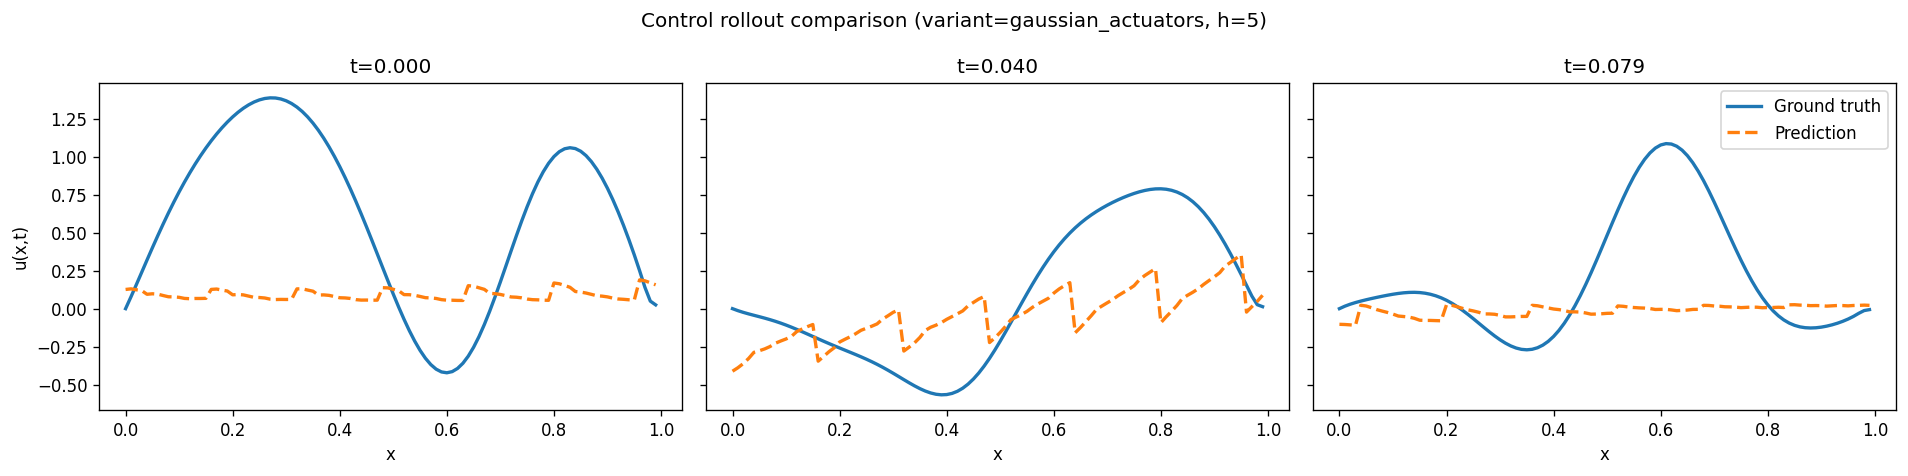

In [46]:
# 12) Single-trajectory rollout and visualization (control-conditioned)
assert rollout_h >= 1

traj_sol = sol_test_chunks[sample_id]  # (n_chunks, chunk_len, nx, 1)
traj_ctrl = ctrl_test_chunks[sample_id]  # (n_chunks, chunk_len, n_ctrl, 1)

if traj_sol.shape[0] != traj_ctrl.shape[0]:
    raise ValueError(
        f"State/control chunk count mismatch: sol={traj_sol.shape[0]}, ctrl={traj_ctrl.shape[0]}"
    )

max_start = traj_sol.shape[0] - n_intervals - rollout_h
if max_start < 0:
    raise ValueError(
        f"Not enough chunks for rollout_h={rollout_h}. Have n_chunks={traj_sol.shape[0]}, n_intervals={n_intervals}."
    )

start = min(start_chunk, max_start)
chunk_len = int(traj_sol.shape[1])
nx = int(traj_sol.shape[2])

u0_chunk = traj_sol[start + n_intervals - 1]  # (chunk_len, nx, 1)
u0 = u0_chunk.permute(2, 0, 1).unsqueeze(0).to(device).float()  # (1,1,chunk_len,nx)

ctrl_seq_chunks = traj_ctrl[
    start + n_intervals - 1 : start + n_intervals - 1 + rollout_h
]  # (rollout_h, chunk_len, n_ctrl, 1)
ctrl_seq = (
    ctrl_seq_chunks.permute(0, 3, 1, 2).unsqueeze(0).to(device).float()
)  # (1,rollout_h,1,chunk_len,n_ctrl)

y_true_chunks = traj_sol[
    start + n_intervals : start + n_intervals + rollout_h
]  # (rollout_h, chunk_len, nx, 1)

ar_model.eval()
with torch.no_grad():
    pred_roll = ar_model.rollout(
        u0=u0, ctrl_seq=ctrl_seq, steps=rollout_h
    )  # (1,rollout_h+1,1,chunk_len,nx)

pred_chunks = (
    pred_roll[:, 1:, 0].permute(0, 1, 3, 2).squeeze(0).unsqueeze(-1).detach().cpu()
)
true_chunks = y_true_chunks.detach().cpu()

pred_flat = pred_chunks.squeeze(-1).reshape(rollout_h * chunk_len, nx)
true_flat = true_chunks.squeeze(-1).reshape(rollout_h * chunk_len, nx)

mse_roll = torch.mean((pred_flat - true_flat) ** 2).item()
rel_l2_roll = (
    torch.linalg.norm(pred_flat - true_flat) / (torch.linalg.norm(true_flat) + 1e-12)
).item()

print(f"u0 shape: {tuple(u0.shape)}")
print(f"ctrl_seq shape: {tuple(ctrl_seq.shape)}")
print(f"pred_chunks shape: {tuple(pred_chunks.shape)}")
print(f"true_chunks shape: {tuple(true_chunks.shape)}")
print(f"Rollout MSE (h={rollout_h}): {mse_roll:.6e}")
print(f"Rollout relative L2 (h={rollout_h}): {rel_l2_roll:.6e}")

x_axis = x_cord.squeeze(-1).cpu().numpy()
t_axis = np.arange(rollout_h * chunk_len) * dt

fig, axes = plt.subplots(1, 3, figsize=(16, 4), dpi=120, sharey=True)
idxs = [0, rollout_h * chunk_len // 2, rollout_h * chunk_len - 1]
for ax, tidx in zip(axes, idxs):
    ax.plot(x_axis, true_flat[tidx].numpy(), label="Ground truth", linewidth=2)
    ax.plot(x_axis, pred_flat[tidx].numpy(), "--", label="Prediction", linewidth=2)
    ax.set_title(f"t={t_axis[tidx]:.3f}")
    ax.set_xlabel("x")
axes[0].set_ylabel("u(x,t)")
axes[-1].legend(loc="best")
plt.suptitle(f"Control rollout comparison (variant={active_variant}, h={rollout_h})")
plt.tight_layout()
plt.show()


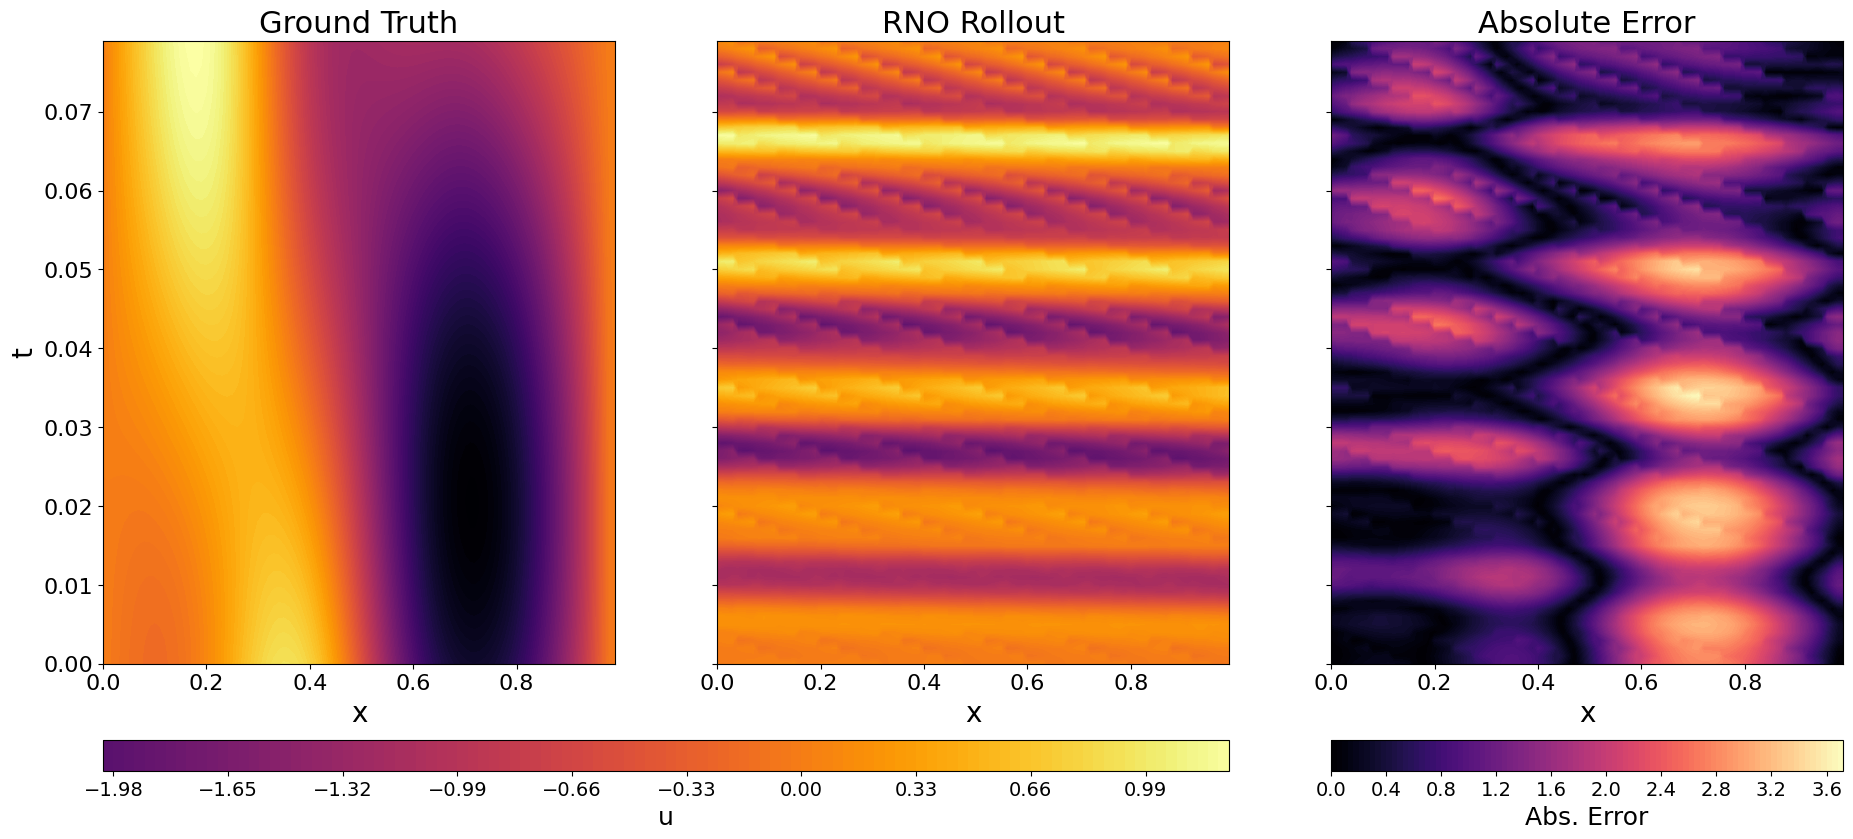

In [40]:
# 12b) Contour-style comparison, matching prior notebook style family
# Uses tensors prepared in the previous section-12 rollout cell: true_flat, pred_flat, x_axis, rollout_h, chunk_len, dt

true_np = true_flat.detach().cpu().numpy()
pred_np = pred_flat.detach().cpu().numpy()
err_np = np.abs(true_np - pred_np)
time_axis = np.linspace(0.0, dt * (rollout_h * chunk_len - 1), rollout_h * chunk_len)

# Save directory for section-12 figures
result_dir = os.path.join("heat", f"result_rno_controls_eval_{seed}")
os.makedirs(result_dir, exist_ok=True)

# If the line plot path wasn't saved in the previous cell, define a placeholder for printing consistency
if "line_plot_path" not in globals():
    line_plot_path = os.path.join(result_dir, f"rollout_lines_h{rollout_h}.png")

# Contour-style comparison, matching prior notebook style family
vmin = float(min(true_np.min(), pred_np.min()))
vmax = float(max(true_np.max(), pred_np.max()))

fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(
    3,
    3,
    height_ratios=[20, 0.3, 1.0],
    width_ratios=[1, 1, 1],
    hspace=0.15,
    wspace=0.2,
    bottom=0.15,
    top=0.88,
    left=0.08,
    right=0.95,
)

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1], sharey=ax0)
ax2 = fig.add_subplot(gs[0, 2], sharey=ax0)

im0 = ax0.contourf(
    x_axis, time_axis, true_np, levels=120, cmap="inferno", vmin=vmin, vmax=vmax
)
ax0.set_title("Ground Truth", fontsize=22)
ax0.set_xlabel("x", fontsize=20)
ax0.set_ylabel("t", fontsize=20)
ax0.tick_params(labelsize=16)

im1 = ax1.contourf(
    x_axis, time_axis, pred_np, levels=120, cmap="inferno", vmin=vmin, vmax=vmax
)
ax1.set_title("RNO Rollout", fontsize=22)
ax1.set_xlabel("x", fontsize=20)
ax1.tick_params(labelsize=16, labelleft=False)

im2 = ax2.contourf(x_axis, time_axis, err_np, levels=120, cmap="magma")
ax2.set_title("Absolute Error", fontsize=22)
ax2.set_xlabel("x", fontsize=20)
ax2.tick_params(labelsize=16, labelleft=False)

cbar_ax1 = fig.add_subplot(gs[2, 0:2])
cbar1 = fig.colorbar(im1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("u", fontsize=18)
cbar1.ax.tick_params(labelsize=14)

cbar_ax2 = fig.add_subplot(gs[2, 2])
cbar2 = fig.colorbar(im2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Abs. Error", fontsize=18)
cbar2.ax.tick_params(labelsize=14)

plt.show()


## 13) Multi-Horizon Endpoint Testing (Single Active Variant)
For each horizon `h`, computes endpoint MSE and relative L2 over sampled test windows for the selected `active_variant`.


In [48]:
# 13) Multi-horizon endpoint evaluation (multistep-finetune aligned)
# Mirrors train_RNO_gaussian_actuators sections 12/16/17 data/eval semantics.


def build_state_control_windows_horizon(
    sol_chunks, ctrl_chunks, n_intervals_inner, horizon_inner
):
    # sol_chunks:  (n_traj, n_chunks, T, nx, 1)
    # ctrl_chunks: (n_traj, n_chunks, T, n_ctrl, 1)
    x_state_list, x_ctrl_hist_list, ctrl_seq_list, y_list = [], [], [], []

    n_chunks = sol_chunks.shape[1]
    max_i = n_chunks - n_intervals_inner - horizon_inner

    for traj_sol, traj_ctrl in zip(sol_chunks, ctrl_chunks):
        for i in range(max_i):
            x_state_hist = traj_sol[i : i + n_intervals_inner]  # (T_hist, T, nx, 1)
            x_ctrl_hist = traj_ctrl[i : i + n_intervals_inner]  # (T_hist, T, n_ctrl, 1)

            # Control alignment: ctrl_k pairs with u_k. u0 is last history state.
            ctrl_seq_h = traj_ctrl[
                i + n_intervals_inner - 1 : i + n_intervals_inner - 1 + horizon_inner
            ]  # (h, T, n_ctrl, 1)

            y_endpoint = traj_sol[
                i + n_intervals_inner + horizon_inner - 1
            ]  # (T, nx, 1)

            x_state_list.append(x_state_hist)
            x_ctrl_hist_list.append(x_ctrl_hist)
            ctrl_seq_list.append(ctrl_seq_h)
            y_list.append(y_endpoint)

    T_local = int(sol_chunks.shape[2])
    nx_local = int(sol_chunks.shape[3])
    n_ctrl_local = int(ctrl_chunks.shape[3])

    if len(x_state_list) == 0:
        x_state_empty = torch.empty(0, n_intervals_inner, 1, T_local, nx_local)
        x_ctrl_hist_empty = torch.empty(0, n_intervals_inner, 1, T_local, n_ctrl_local)
        ctrl_seq_empty = torch.empty(0, horizon_inner, 1, T_local, n_ctrl_local)
        y_empty = torch.empty(0, 1, T_local, nx_local)
        return (
            x_state_empty.float(),
            x_ctrl_hist_empty.float(),
            ctrl_seq_empty.float(),
            y_empty.float(),
        )

    x_state = torch.stack(x_state_list, dim=0).float()  # (N, T_hist, T, nx, 1)
    x_ctrl_hist = torch.stack(
        x_ctrl_hist_list, dim=0
    ).float()  # (N, T_hist, T, n_ctrl, 1)
    ctrl_seq = torch.stack(ctrl_seq_list, dim=0).float()  # (N, h, T, n_ctrl, 1)
    y_endpoint = torch.stack(y_list, dim=0).float()  # (N, T, nx, 1)

    x_state = x_state.permute(0, 1, 4, 2, 3).contiguous()  # (N, T_hist, 1, T, nx)
    x_ctrl_hist = x_ctrl_hist.permute(
        0, 1, 4, 2, 3
    ).contiguous()  # (N, T_hist, 1, T, n_ctrl)
    ctrl_seq = ctrl_seq.permute(0, 1, 4, 2, 3).contiguous()  # (N, h, 1, T, n_ctrl)
    y_endpoint = y_endpoint.permute(0, 3, 1, 2).contiguous()  # (N, 1, T, nx)

    return x_state, x_ctrl_hist, ctrl_seq, y_endpoint


def evaluate_endpoint_metrics(
    ar_model_obj, eval_loaders_by_h, eval_steps_inner, device_inner
):
    ar_model_obj.eval()
    results = {}
    printed_shapes = False

    with torch.no_grad():
        for h in eval_steps_inner:
            if h not in eval_loaders_by_h:
                raise ValueError(f"No evaluation loader for horizon h={h}")

            loader = eval_loaders_by_h[h]
            mse_sum = 0.0
            rel_sum = 0.0
            n_total = 0

            for x_state_hist, x_ctrl_hist, x_ctrl_seq, y_endpoint in loader:
                x_state_hist = x_state_hist.to(
                    device_inner
                ).float()  # (B,T_hist,1,T,nx)
                x_ctrl_hist = x_ctrl_hist.to(
                    device_inner
                ).float()  # (B,T_hist,1,T,n_ctrl)
                x_ctrl_seq = x_ctrl_seq.to(device_inner).float()  # (B,h,1,T,n_ctrl)
                y_endpoint = y_endpoint.to(device_inner).float()  # (B,1,T,nx)

                u0 = x_state_hist[:, -1]  # (B,1,T,nx)
                ctrl_seq_h = x_ctrl_seq[:, :h]  # (B,h,1,T,n_ctrl)

                pred_roll = ar_model_obj.rollout(u0=u0, ctrl_seq=ctrl_seq_h, steps=h)
                y_pred_endpoint = pred_roll[:, -1]  # (B,1,T,nx)

                if not printed_shapes:
                    print("x_state_hist:", tuple(x_state_hist.shape))
                    print("x_ctrl_hist:", tuple(x_ctrl_hist.shape))
                    print("ctrl_seq used:", tuple(ctrl_seq_h.shape))
                    print("y_true endpoint:", tuple(y_endpoint.shape))
                    print("y_pred endpoint:", tuple(y_pred_endpoint.shape))
                    printed_shapes = True

                assert y_pred_endpoint.shape == y_endpoint.shape, (
                    y_pred_endpoint.shape,
                    y_endpoint.shape,
                )

                diff_flat = (y_pred_endpoint - y_endpoint).reshape(
                    y_endpoint.shape[0], -1
                )
                y_flat = y_endpoint.reshape(y_endpoint.shape[0], -1)

                mse_per = torch.mean((diff_flat) ** 2, dim=1)
                rel_per = torch.linalg.norm(diff_flat, dim=1) / (
                    torch.linalg.norm(y_flat, dim=1) + 1e-12
                )

                mse_sum += mse_per.sum().item()
                rel_sum += rel_per.sum().item()
                n_total += y_endpoint.shape[0]

            results[h] = {
                "mse": mse_sum / max(n_total, 1),
                "rel_l2": rel_sum / max(n_total, 1),
                "N": int(n_total),
            }

    print("Horizon | N | MSE | Rel. L2")
    print("---------------------------")
    for h in eval_steps_inner:
        print(
            f"{h:>7} | {results[h]['N']:>6} | {results[h]['mse']:.6e} | {results[h]['rel_l2']:.6e}"
        )

    return results


# Build horizon-specific test tensors/loaders like multistep training notebook.
multi_step_test_data = {}
multi_step_test_eval_loaders = {}

eval_steps = [1, 2, 4, 5, 8, 12]


for h in eval_steps:
    x_state_te, x_ctrl_hist_te, x_ctrl_seq_te, y_te = (
        build_state_control_windows_horizon(
            sol_test_chunks,
            ctrl_test_chunks,
            n_intervals,
            h,
        )
    )
    if x_state_te.shape[0] == 0:
        raise ValueError(
            f"No samples available for horizon h={h}. Insufficient future steps/controls."
        )

    multi_step_test_data[h] = (x_state_te, x_ctrl_hist_te, x_ctrl_seq_te, y_te)
    multi_step_test_eval_loaders[h] = DataLoader(
        torch.utils.data.TensorDataset(x_state_te, x_ctrl_hist_te, x_ctrl_seq_te, y_te),
        batch_size=batch_size_eval,
        shuffle=False,
        drop_last=False,
    )

endpoint_eval_results = evaluate_endpoint_metrics(
    ar_model_obj=ar_model,
    eval_loaders_by_h=multi_step_test_eval_loaders,
    eval_steps_inner=eval_steps,
    device_inner=device,
)


x_state_hist: (128, 5, 1, 16, 100)
x_ctrl_hist: (128, 5, 1, 16, 4)
ctrl_seq used: (128, 1, 1, 16, 4)
y_true endpoint: (128, 1, 16, 100)
y_pred endpoint: (128, 1, 16, 100)
Horizon | N | MSE | Rel. L2
---------------------------
      1 |   1520 | 8.040249e-01 | 6.790343e-01
      2 |   1440 | 5.177387e-01 | 5.686858e-01
      4 |   1280 | 4.104952e-01 | 5.414189e-01
      5 |   1200 | 3.902187e-01 | 5.413651e-01
      8 |    960 | 3.594543e-01 | 5.474778e-01
     12 |    640 | 3.445842e-01 | 5.539662e-01
